# 12B - the wide bullet: off-center crossings

Notebook 12 tested a bullet built as two points joined by a rigid rod:
length, no width. Its result: a bubble boundary never turns that bullet
unless the rod is already tilted away from its direction of flight. Elliott
pushed back:

> What about the bullet not hitting the sphere not dead on, and so you have
> an off center acceleration pulling on the bullet, relative to the other
> half of the bullet. It isn't just front and back along the line of
> trajectory. And, this is very likely closer to the book scenario [...]
> What are the o[dd]s of someone shooting a perfect perpendicular impact at
> wayne? It's statistically probably nearly impossible.

His point: a real shot at Wayne almost never crosses the bubble dead-center.
This notebook tests what an off-center crossing does to a body that has
width. To be clear about credit: the off-center question is Elliott's; the
width construction below (a side-by-side pair, then a four-point frame) was
Claude's proposal for how to test it.

Terms used in this notebook, defined once:

- **Miss distance**: how far the flight line misses the bubble's center.
  0 is dead-center; 5 m grazes the edge of our standard 5 m bubble.
  (Physics calls this the impact parameter.)
- **Ground truth**: the slow, careful version of an experiment, run once to
  check the fast version against. Ours is built from stiff springs, because
  springs use only force rules the engine already has.
- **Tick-rate sweep**: the same experiment run with smaller and smaller
  time steps. If the answer settles, it is real. If it keeps moving, it is
  the time step talking.
- **Half-in**: the stretch of ticks when part of the body is inside the
  bubble and the rest is still outside (same term as notebook 12).
- **Crossing gap**: the distance the body travels between its first point
  crossing the boundary and its last point crossing.
- **Heading**: the direction of travel, in degrees. A heading change is a
  turn.
- **Spin**: how fast the body rotates, in degrees per second.

Predictions on paper, before any run. At miss distance 0 the shot is the
same above its centerline as below: the two side points reach the bubble at
the same instant, everything that happens to one happens equally to the
other, and the body cannot turn. If the sim shows a turn at miss distance
0, the sim is broken. Off-center, the side nearer the bubble's middle
enters first and runs five times faster while its partner is still slow.
That uneven pull is sideways and off the body's center, so the body should
turn and spin, and more so as the miss distance grows. Expected direction:
the early side surges ahead, which swings the body away from the bubble's
center - the bubble should spread wide bodies outward, the way a lens can
spread light.

Gravity is cancelled in every run here, so the flight is a straight line
and any bend is the bubble's doing. The facts this notebook leans on from
notebook 12: a bubble boundary slows extended bodies at every crossing
(stored speed times (1+f)^2 / (2(1+f^2)) per crossing, f the bubble
factor), and results must settle in a tick-rate sweep and match ground
truth before they count.


In [1]:
import sys
sys.path.insert(0, "..")

import itertools

import numpy as np
import matplotlib.pyplot as plt

from sim import (Body, World, SpeedBubble, RigidConstraint, RigidFrame,
                 GRAVITY_M_PER_S2)

LAUNCH_SPEED = 50.0
PAIR_WIDTH_M = 0.1            # the transverse pair: two 10 g tips, 10 cm apart
BULLET_LENGTH_M = 0.2        # the wide bullet: 20 cm long...
BULLET_WIDTH_M = 0.05        # ...and 5 cm wide, 5 g per corner
BUBBLE = dict(center=(10, 10), radius_m=5, time_factor=5.0)
BUBBLE_CENTER = np.array([10.0, 10.0])


class AntiGravity:
    """Cancels gravity so any heading change is the boundary's work alone."""

    def __init__(self, bodies):
        self.bodies = bodies

    def apply_forces(self):
        for body in self.bodies:
            body.apply_force([0.0, GRAVITY_M_PER_S2 * body.mass_kg])


class SpringRod:
    """Ground-truth rigid rod (the ground-truth rod from notebook 12): equal-and-opposite
    spring + damper forces, the engine's force rule, run at a tiny
    timestep where it is stable everywhere."""

    def __init__(self, world, body_a, body_b, length_m, stiffness, damping):
        self.world, self.body_a, self.body_b = world, body_a, body_b
        self.length_m, self.stiffness, self.damping = length_m, stiffness, damping

    def apply_forces(self):
        offset = self.body_a.position - self.body_b.position
        distance = float(np.linalg.norm(offset))
        if distance < 1e-9:
            return
        direction = offset / distance
        factor_a = self.world.time_factor_at(self.body_a.position)
        factor_b = self.world.time_factor_at(self.body_b.position)
        separation_rate = np.dot(self.body_a.velocity * factor_a
                                 - self.body_b.velocity * factor_b, direction)
        force = (-self.stiffness * (distance - self.length_m)
                 - self.damping * separation_rate)
        self.body_a.apply_force(force * direction)
        self.body_b.apply_force(-force * direction)


class SpringFrame:
    """Ground-truth rigid frame: a SpringRod on every edge."""

    def __init__(self, world, bodies, stiffness, damping):
        self.rods = [SpringRod(world, body_a, body_b,
                               float(np.linalg.norm(body_a.position - body_b.position)),
                               stiffness, damping)
                     for body_a, body_b in itertools.combinations(bodies, 2)]

    def apply_forces(self):
        for rod in self.rods:
            rod.apply_forces()


def make_side_by_side_pair(world, miss_distance_m, rig="projection"):
    flight_y = BUBBLE_CENTER[1] + miss_distance_m
    up = world.add_body(Body("up", 0.01, (0.0, flight_y + PAIR_WIDTH_M / 2),
                             velocity=(LAUNCH_SPEED, 0), radius_m=0.01))
    down = world.add_body(Body("down", 0.01, (0.0, flight_y - PAIR_WIDTH_M / 2),
                               velocity=(LAUNCH_SPEED, 0), radius_m=0.01))
    if rig == "projection":
        world.add_power(RigidConstraint(up, down, PAIR_WIDTH_M))
    else:
        world.add_power(SpringRod(world, up, down, PAIR_WIDTH_M, 8e4, 40.0))
    return [up, down]


def make_wide_bullet(world, miss_distance_m, rig="projection"):
    center_y = BUBBLE_CENTER[1] + miss_distance_m
    spots = [(BULLET_LENGTH_M / 2, center_y), (-BULLET_LENGTH_M / 2, center_y),
             (0.0, center_y + BULLET_WIDTH_M / 2), (0.0, center_y - BULLET_WIDTH_M / 2)]
    bodies = [world.add_body(Body(name, 0.005, spot,
                                  velocity=(LAUNCH_SPEED, 0), radius_m=0.005))
              for name, spot in zip(["nose", "tail", "left", "right"], spots)]
    if rig == "projection":
        world.add_power(RigidFrame(bodies))
    else:
        # Softer constants than the two-point ground-truth rod: the corners are half the
        # mass, and the damper's per-tick gain must stay well under 1.
        world.add_power(SpringFrame(world, bodies, 2e4, 4.0))
    return bodies


def body_state(bodies, axis_pair=(0, 1), axis_length=None):
    """center-of-mass heading (degrees), speed, and spin (deg/s) measured from the
    relative velocity of the two bodies named by axis_pair."""
    center_of_mass_velocity = sum(body.velocity for body in bodies) / len(bodies)
    first, second = bodies[axis_pair[0]], bodies[axis_pair[1]]
    axis = first.position - second.position
    length = float(np.linalg.norm(axis)) if axis_length is None else axis_length
    axis = axis / np.linalg.norm(axis)
    relative = first.velocity - second.velocity
    tangential = relative - np.dot(relative, axis) * axis
    spin = np.degrees(np.linalg.norm(tangential) / length)
    heading = np.degrees(np.arctan2(center_of_mass_velocity[1], center_of_mass_velocity[0]))
    return heading, float(np.linalg.norm(center_of_mass_velocity)), spin


def run_transit(world, bodies, hz, max_seconds=2.0):
    """Step until the body is done with the bubble: every point well outside
    and the center of mass receding from the bubble's center."""
    for _ in range(int(max_seconds * hz)):
        world.step()
        center_of_mass_position = sum(body.position for body in bodies) / len(bodies)
        center_of_mass_velocity = sum(body.velocity for body in bodies) / len(bodies)
        clear = all(np.linalg.norm(body.position - BUBBLE_CENTER) > 5.2
                    for body in bodies)
        if clear and np.dot(center_of_mass_velocity, center_of_mass_position - BUBBLE_CENTER) > 0:
            return
    raise RuntimeError("body never cleared the bubble")


def run_to_entry(world, bodies, hz, settle_seconds=0.004, max_seconds=0.4):
    """Step until every point is inside the bubble, plus a settle margin:
    the entry boundary's work is complete, the exit hasn't begun. While
    fully inside, all points share one clock, so the center-of-mass velocity is
    frozen and the measurement is stable."""
    report_time = None
    for _ in range(int(max_seconds * hz)):
        world.step()
        all_inside = all(np.linalg.norm(body.position - BUBBLE_CENTER) < 5
                         for body in bodies)
        if all_inside and report_time is None:
            report_time = world.time_seconds + settle_seconds
        if report_time is not None and world.time_seconds >= report_time:
            return
    raise RuntimeError("body never got fully inside the bubble")

## Experiment A - the side-by-side pair: width with no length

Two balls, 10 cm apart, joined by an invisible rigid rod that stands
crossways to the direction of flight - a telephone pole flying sideways.
The rod cannot be tilted relative to its motion any further than it already
is, so anything that happens here comes from width alone.

One time-step rule before the table. The turn happens while the body is
half-in, and that stretch lasts from the first ball crossing the boundary
to the second ball crossing - the crossing gap. If the body travels further
than the crossing gap in a single tick, both balls switch zones in the same
tick, and the sim reports a perfectly even crossing that never happened. At
miss distance 0.5 the crossing gap is about 1 cm, and at 4000 Hz the pair
travels 1.25 cm per tick - so the 0.5 row below is a known fake zero, kept
in the table as a warning label.


In [2]:
print("side-by-side pair, full transit at 4000 Hz (gravity-free; launch heading 0 deg, speed 50):")
print(f"{'miss m':>6}  {'exit heading':>13}  {'exit speed':>11}  {'exit spin':>12}")
for miss_distance in [0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 4.5]:
    world = World(dt_seconds=1.0 / 4000)
    pair = make_side_by_side_pair(world, miss_distance)
    world.add_power(AntiGravity(pair))
    world.add_bubble(SpeedBubble(**BUBBLE))
    run_transit(world, pair, 4000)
    heading, speed, spin = body_state(pair, axis_length=PAIR_WIDTH_M)
    note = "   <- fake zero: crossing gap < one tick of travel" if miss_distance == 0.5 else ""
    print(f"{miss_distance:6.1f}  {heading:+12.4f} deg  {speed:9.3f} m/s  {spin:9.1f} deg/s{note}")

side-by-side pair, full transit at 4000 Hz (gravity-free; launch heading 0 deg, speed 50):
miss m   exit heading   exit speed     exit spin
   0.0       +0.0000 deg     50.000 m/s        0.0 deg/s
   0.5       +0.0000 deg     50.000 m/s        0.0 deg/s   <- fake zero: crossing gap < one tick of travel
   1.0       +7.4716 deg     47.325 m/s     4811.0 deg/s
   2.0      +19.1973 deg     41.675 m/s     4603.1 deg/s
   3.0      +24.2161 deg     29.742 m/s     6666.7 deg/s
   4.0      +60.8357 deg     29.107 m/s    10885.2 deg/s
   4.5      +42.1410 deg     33.406 m/s     6807.7 deg/s


Both paper predictions hold. Dead-center is exactly zero. Real miss
distances turn the pair by tens of degrees - always away from the bubble's
center - with spin in the thousands of degrees per second, and the pair
comes out slower than it went in.

Two cautions before trusting these numbers, both learned in notebook 12.
First, these are full trips through the bubble, and the exit crossing's
result depends on the angle the spinning body happens to hold when it
exits. The body spins fast enough that no practical time step pins that
angle down, so the wiggle between the 4.0 and 4.5 rows is expected scatter,
not structure. Second, full-trip numbers change with tick rate for the same
reason. For settled numbers, we measure right after entry instead - once
the whole body is inside, its overall velocity stops changing until the
exit begins - and we check against ground truth.


In [3]:
print("entry of the side-by-side pair at miss distance 2, tick-rate sweep:")
for hz in [2000, 4000, 8000, 16000, 32000]:
    world = World(dt_seconds=1.0 / hz)
    pair = make_side_by_side_pair(world, 2.0)
    world.add_power(AntiGravity(pair))
    world.add_bubble(SpeedBubble(**BUBBLE))
    run_to_entry(world, pair, hz)
    heading, speed, spin = body_state(pair, axis_length=PAIR_WIDTH_M)
    print(f"  projection {hz:6d} Hz: heading {heading:+8.3f} deg, "
          f"speed {speed:7.3f} m/s, spin {spin:8.0f} deg/s")

world = World(dt_seconds=1.0 / 200_000)
pair = make_side_by_side_pair(world, 2.0, rig="spring")
world.add_power(AntiGravity(pair))
world.add_bubble(SpeedBubble(**BUBBLE))
run_to_entry(world, pair, 200_000)
heading, speed, spin = body_state(pair, axis_length=PAIR_WIDTH_M)
print(f"  spring    200000 Hz: heading {heading:+8.3f} deg, "
      f"speed {speed:7.3f} m/s, spin {spin:8.0f} deg/s   <- ground truth")

entry of the side-by-side pair at miss distance 2, tick-rate sweep:
  projection   2000 Hz: heading  +10.305 deg, speed  43.001 m/s, spin     6481 deg/s
  projection   4000 Hz: heading  +12.853 deg, speed  43.673 m/s, spin     8352 deg/s


  projection   8000 Hz: heading  +17.115 deg, speed  41.832 m/s, spin    11859 deg/s
  projection  16000 Hz: heading  +20.943 deg, speed  39.127 m/s, spin    16345 deg/s
  projection  32000 Hz: heading  +22.030 deg, speed  39.003 m/s, spin    19285 deg/s


  spring    200000 Hz: heading  +23.633 deg, speed  37.955 m/s, spin    26204 deg/s   <- ground truth


Ground truth at miss distance 2: the entry turns the pair +23.6 deg and
spins it up to about 26,000 deg/s - roughly 70 revolutions per second. The
cheap projection climbs toward those numbers from below as the time step
shrinks, and it climbs more slowly than notebook 12's experiments did. The
reason is the spin itself: at 70 revolutions per second the balls swing at
about 20 m/s, comparable to the flight speed, so they cross back and forth
over the boundary while the body is half-in, and each re-crossing adds
detail that only finer ticks catch. Practical consequence, stated for the
record: at game-feasible tick rates the sim understates the effect. The
real turn and spin are stronger than the cheap version shows, never weaker.

So width alone is enough. No tilt needed - just the off-center arrival
that every real shot has. Now the real object.


## Experiment B - the wide bullet

Four points, rigidly framed: 20 cm nose to tail, 5 cm across, 5 g per
corner, flying nose-first with zero tilt. This is notebook 12's bullet -
the one that could never turn - plus width. The frame is
`sim/rigid_frame.py`: every edge of the frame gets the same
length-restoring correction the two-point rod used, applied edge by edge
and repeated a few times each tick until the shape is right. In plain
flight it holds its shape to within 1e-15 m and conserves momentum exactly
(probe-checked).


In [4]:
print("wide bullet, full transit at 4000 Hz, nose-first, zero tilt:")
print(f"{'miss m':>6}  {'exit heading':>13}  {'exit speed':>11}  {'exit spin':>12}")
for miss_distance in [0.0, 1.0, 2.0, 3.0, 4.0]:
    world = World(dt_seconds=1.0 / 4000)
    bullet = make_wide_bullet(world, miss_distance)
    world.add_power(AntiGravity(bullet))
    world.add_bubble(SpeedBubble(**BUBBLE))
    run_transit(world, bullet, 4000)
    heading, speed, spin = body_state(bullet, axis_length=BULLET_LENGTH_M)
    print(f"{miss_distance:6.1f}  {heading:+12.4f} deg  {speed:9.3f} m/s  {spin:9.0f} deg/s")

# The miss distance 0 exit speed gets its own check: an independent spring-frame
# ground truth at 50 kHz (softer constants, stable, still 12x finer than
# any projection run above).
world = World(dt_seconds=1.0 / 50_000)
bullet = make_wide_bullet(world, 0.0, rig="spring")
world.add_power(AntiGravity(bullet))
world.add_bubble(SpeedBubble(**BUBBLE))
run_transit(world, bullet, 50_000)
heading, speed, spin = body_state(bullet, axis_length=BULLET_LENGTH_M)
print(f"\nspring-frame ground truth, miss distance 0: exit speed {speed:.3f} m/s")
print(f"(the two-point rod of notebook 12 kept {50 * 81 / 169:.3f} m/s; "
      "the frame is slowed at four separate crossings, not two)")

wide bullet, full transit at 4000 Hz, nose-first, zero tilt:
miss m   exit heading   exit speed     exit spin


   0.0       -0.0036 deg     14.653 m/s          4 deg/s


   1.0       -3.0426 deg     13.638 m/s         29 deg/s


   2.0       -4.3818 deg     14.438 m/s       2312 deg/s


   3.0       +0.3464 deg     14.412 m/s       2185 deg/s


   4.0       +4.3946 deg     16.547 m/s       2644 deg/s



spring-frame ground truth, miss distance 0: exit speed 14.651 m/s
(the two-point rod of notebook 12 kept 23.964 m/s; the frame is slowed at four separate crossings, not two)


Reading the table:

- **Miss distance 0 stays honest.** Turn and spin are zero to numerical
  noise, so the frame's extra structure did not sneak in an imbalance. The
  exit speed is the news: 14.65 m/s, 29% of launch, against the two-point
  rod's 48%. The projection and the independent spring-built ground truth
  agree to three decimals. Notebook 12 found that each boundary crossing
  slows an extended body; the frame's four points cross at four separate
  moments, and each crossing takes its cut. A real bullet - solid metal,
  points everywhere - presumably loses more still; the four-point frame is
  the gentlest version.
- **Any real miss distance sets the bullet tumbling, nose-first or not.**
  Thousands of degrees per second of spin acquired with zero tilt, plus a
  turn that scatters with the exit angle. Notebook 12's no-turn result is
  now properly scoped: it was a statement about zero-width bodies, and
  zero-width bodies do not exist.


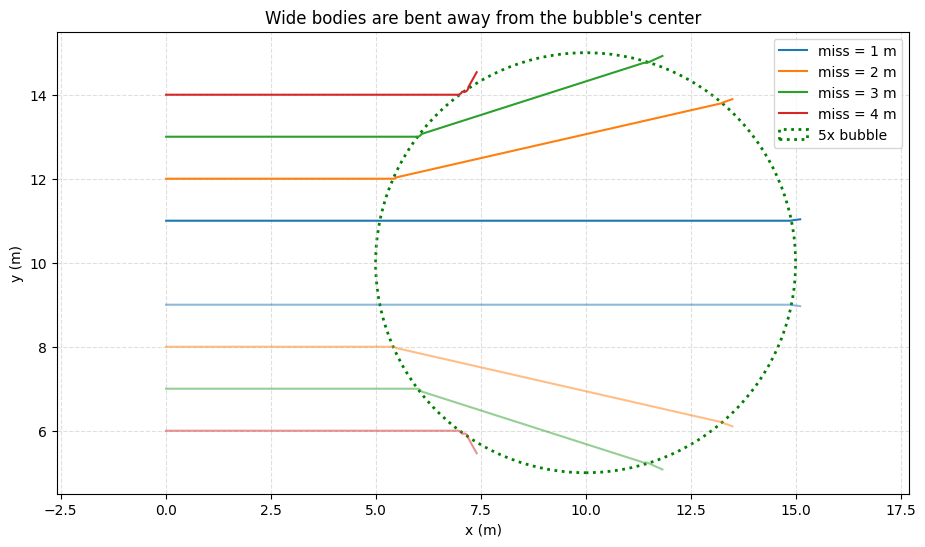

In [5]:
# Paths of the side-by-side pair for several miss distances. Gravity
# is cancelled, so every bend is the bubble's doing.
plt.figure(figsize=(11, 6))
for miss_distance in [1.0, 2.0, 3.0, 4.0]:
    for sign in (+1, -1):  # mirror shots below the centerline: lens symmetry
        world = World(dt_seconds=1.0 / 4000)
        pair = make_side_by_side_pair(world, sign * miss_distance)
        world.add_power(AntiGravity(pair))
        world.add_bubble(SpeedBubble(**BUBBLE))
        run_transit(world, pair, 4000, max_seconds=1.0)
        up_path = world.history.body("up")
        down_path = world.history.body("down")
        com_x = (np.array(up_path["x"]) + np.array(down_path["x"])) / 2
        com_y = (np.array(up_path["y"]) + np.array(down_path["y"])) / 2
        if sign > 0:
            plt.plot(com_x, com_y, label=f"miss = {miss_distance:.0f} m")
        else:
            plt.plot(com_x, com_y,
                     color=plt.gca().lines[-1].get_color(), alpha=0.5)

circle = plt.Circle(BUBBLE["center"], BUBBLE["radius_m"], color="green",
                    fill=False, linestyle=":", linewidth=2, label="5x bubble")
plt.gca().add_patch(circle)
plt.axis("equal")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Wide bodies are bent away from the bubble's center")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

## Findings

1. **Width changes the answer.** A body with width crossing the boundary
   off-center is turned and spun with zero tilt. Notebook 12's no-turn
   result applies only to zero-width bodies, which is to say, to nothing
   real. Elliott raised the off-center hit; the width construction followed
   from his question.
2. **Dead-center is exactly zero, and never happens.** Turn and spin at
   miss distance 0 are zero by symmetry (verified to numerical zero,
   probe-checked), and a dead-center hit needs the flight line to pass
   exactly through the bubble's center - a zero-probability shot. Every
   real shot tumbles.
3. **The bubble spreads wide bodies away from its center**, symmetric above
   and below - see the path figure. Tens of degrees at moderate miss
   distances; ground truth puts the entry turn at +23.6 deg for the
   side-by-side pair at miss distance 2.
4. **The spin is violent and the cheap sim understates it.** Ground truth:
   about 26,000 deg/s (70 revolutions per second) at miss distance 2. The
   projection climbs toward that from below, because the spinning balls
   re-cross the boundary mid-entry and only finer ticks catch it.
   Time-step rule: the crossing gap, not the body size, sets the tick
   needed - and the fake-even crossing (the 0.5 row) is the failure to
   watch for.
5. **More structure, more slow-down.** The four-point frame exits a
   dead-center crossing at 29% of launch speed; notebook 12's two-point rod
   kept 48%. Projection 14.653 m/s, ground truth 14.651. What a continuous
   body loses is an open question for a future notebook.
6. **The path to the books' deflected bullets is now mechanical, one piece
   short.** Boundary turn and spin (this notebook) plus air drag (not built
   yet) equals a tumbling bullet that loses its line and misses. Air drag
   is next. Even without air, the bubble already slows bullets to half
   speed or less, bends them off their line, and sets them tumbling.

Probe checks pin findings 1, 2, and 5:
`check_rigid_frame_holds_shape_and_momentum`,
`check_dead_center_crossing_is_symmetric`,
`check_off_center_crossing_turns_and_spins`,
`check_wide_bullet_slows_at_each_crossing`.
